# Χρονοπρογραμματισμός Κρίσιμης Διαδρομής της Κυκλοφορίας ενός Προϊόντος Ασφάλισης Αυτοκινήτου

## Συνοπτική παρουσίαση

Η κυκλοφορία ενός προϊόντος προσωπικής ασφάλισης αυτοκινήτου είναι ένα διαλειτουργικό πρόγραμμα: οι αναλογιστές τιμολογούν τον κίνδυνο, η συμμόρφωση καταθέτει τα ασφάλιστρα στην πολιτεία και περιμένει την έγκριση, το τμήμα πληροφορικής παραμετροποιεί το σύστημα διαχείρισης συμβολαίων και η διανομή εκπαιδεύει τους πράκτορες. Αυτές οι εργασίες έχουν αυστηρές σχέσεις προτεραιότητας, οπότε η ημερομηνία κυκλοφορίας καθορίζεται από τη μακρύτερη εξαρτημένη αλυσίδα μέσα στο σχέδιο -- την **κρίσιμη διαδρομή**.

Αυτό το notebook κατασκευάζει ένα δίκτυο έργου τύπου Activity-on-Node με έντεκα εργασίες κυκλοφορίας και υπολογίζει ένα πλήρες χρονοδιάγραμμα με τη **Μέθοδο Κρίσιμης Διαδρομής (CPM)** χρησιμοποιώντας το **PROC OPTMODEL**. Οι εμπρός και πίσω περάσεις της CPM είναι γραμμικά προγράμματα πάνω στον γράφο προτεραιοτήτων: η εμπρός πέραση (μακρύτερη διαδρομή από την αρχή) δίνει την πρωιμότερη έναρξη και λήξη κάθε εργασίας, ενώ μια πίσω πέραση μακρύτερης διαδρομής δίνει την οψιμότερη έναρξη και λήξη και το **συνολικό περιθώριο** (χαλαρότητα του χρονοδιαγράμματος). Τα παρακάτω αποτελέσματα παράγονται εξ ολοκλήρου από τον κώδικα αυτού του notebook -- κάθε αριθμός στην αφήγηση διαβάζεται πίσω από την εκτελεσμένη έξοδο.

**Τι δείχνει το χρονοδιάγραμμα.** Σε ένα ημερολόγιο εργασίας πέντε ημερών με αγκύρωση στην 01JUN2026, το πρόγραμμα εκτείνεται σε **97 εργάσιμες ημέρες** και ολοκληρώνεται στην **13OCT2026**. Εννέα από τις έντεκα εργασίες βρίσκονται στην κρίσιμη διαδρομή (Έναρξη -> Έρευνα αγοράς -> Συγκέντρωση δεδομένων ζημιών -> Τιμολόγηση -> Σχεδιασμός συστήματος -> Κατασκευή συστήματος -> Δοκιμές αποδοχής (UAT) -> Εκπαίδευση πρακτόρων -> Κυκλοφορία) και φέρουν μηδενικό περιθώριο. Μόνο ο ρυθμιστικός κλάδος -- **κατάθεση ασφαλίστρων** και **έγκριση** -- έχει χαλαρότητα: καθένας μπορεί να καθυστερήσει έως και **30 εργάσιμες ημέρες** χωρίς να μετακινήσει την κυκλοφορία, επειδή ο παράλληλος κλάδος κατασκευής του συστήματος είναι ο μακρύτερος από τις δύο συγκλίνουσες διαδρομές.

## Πώς κατασκευάζεται αυτό

Η CPM είναι κλασικά μια διαδικασία του SAS/OR, αλλά ο πυρήνας του υπολογισμού της είναι ένα ζεύγος προβλημάτων μακρύτερης διαδρομής πάνω στον γράφο προτεραιοτήτων, τα οποία το PROC OPTMODEL εκφράζει άμεσα ως μικρά γραμμικά προγράμματα:

- **Εμπρός πέραση (πρωιμότεροι χρόνοι).** Ελαχιστοποιήστε τις μεταβλητές πρωιμότερης έναρξης υπό τον περιορισμό `ES[successor] >= ES[predecessor] + duration + lag` για κάθε τόξο προτεραιότητας. Στο βέλτιστο, κάθε `ES` ισούται με τη μακρύτερη διαδρομή από την αρχή του έργου, δηλαδή με το πρωιμότερο σημείο στο οποίο μπορεί να ξεκινήσει η εργασία.
- **Πίσω πέραση (οψιμότεροι χρόνοι / περιθώριο).** Υπολογίστε, για κάθε εργασία, τη μακρύτερη εναπομείνασα διαδρομή έως το τέλος του έργου (`TAIL`). Η οψιμότερη έναρξη είναι τότε `makespan - TAIL`, και το **συνολικό περιθώριο** είναι `late start - early start`. Οι εργασίες με μηδενικό περιθώριο είναι κρίσιμες.

Το δίκτυο, οι διάρκειες, οι καθυστερήσεις προτεραιότητας και οι απαιτήσεις πόρων ανά εργασία παράγονται όλα ενσωματωμένα· δεν υπάρχουν εξωτερικές είσοδοι. Οι ημερολογιακές ημερομηνίες εργάσιμων ημερών προκύπτουν με το `INTNX('weekday', ...)` ώστε τα σαββατοκύριακα να παραλείπονται.

## Δεδομένα

| Σύνολο δεδομένων | Γραμμές | Βασικές μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Κύριο αρχείο δραστηριοτήτων: κάθε εργασία κυκλοφορίας, η διάρκειά της σε εργάσιμες ημέρες και ο ημερήσιος αριθμός αναλογιστών / προγραμματιστών που χρειάζεται |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Τόξα προτεραιότητας του δικτύου Activity-on-Node· το `lag` είναι μια καθυστέρηση λήξης-προς-έναρξη σε εργάσιμες ημέρες (η ρυθμιστική περίοδος αναμονής μετά την έγκριση) |

Αριθμητικά αναγνωριστικά δραστηριότητας κλειδώνουν το δίκτυο ώστε ο γράφος προτεραιοτήτων να διαβάζεται καθαρά στο σύνολο πλειάδων του OPTMODEL· τα ευανάγνωστα ονόματα `activity` συγχωνεύονται πίσω στο χρονοδιάγραμμα εκ των υστέρων.

In [1]:
ΔΕΔΟΜΕΝΑ acts;
   LENGTH activity $64;
   ΕΙΣΟΔΟΣ id dur actuary developer;
   ΕΑΝ      id=1  ΤΟΤΕ activity='Έναρξη';
   ΑΛΛΙΩΣ ΕΑΝ id=2  ΤΟΤΕ activity='Έρευνα αγοράς';
   ΑΛΛΙΩΣ ΕΑΝ id=3  ΤΟΤΕ activity='Συγκέντρωση δεδομένων ζημιών';
   ΑΛΛΙΩΣ ΕΑΝ id=4  ΤΟΤΕ activity='Τιμολόγηση';
   ΑΛΛΙΩΣ ΕΑΝ id=5  ΤΟΤΕ activity='Κατάθεση ασφαλίστρων';
   ΑΛΛΙΩΣ ΕΑΝ id=6  ΤΟΤΕ activity='Έγκριση';
   ΑΛΛΙΩΣ ΕΑΝ id=7  ΤΟΤΕ activity='Σχεδιασμός συστήματος';
   ΑΛΛΙΩΣ ΕΑΝ id=8  ΤΟΤΕ activity='Κατασκευή συστήματος';
   ΑΛΛΙΩΣ ΕΑΝ id=9  ΤΟΤΕ activity='Δοκιμές αποδοχής (UAT)';
   ΑΛΛΙΩΣ ΕΑΝ id=10 ΤΟΤΕ activity='Εκπαίδευση πρακτόρων';
   ΑΛΛΙΩΣ ΕΑΝ id=11 ΤΟΤΕ activity='Κυκλοφορία';
   DATALINES;
1 3 1 0
2 8 2 0
3 10 3 0
4 9 3 1
5 4 1 0
6 6 1 0
7 12 1 2
8 18 0 3
9 15 0 2
10 20 1 1
11 2 1 1
;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ arcs;
   ΕΙΣΟΔΟΣ pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
ΕΚΤΕΛΕΣΗ;

/* numeric-only view of durations for OPTMODEL */
ΔΕΔΟΜΕΝΑ acts_n; ΟΡΙΣΜΟΣ acts; ΚΡΑΤΗΣΗ id dur; ΕΚΤΕΛΕΣΗ;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Εμπρός πέραση -- πρωιμότερη έναρξη και λήξη

Η εμπρός πέραση είναι ένα LP μακρύτερης διαδρομής. Ο περιορισμός `ES[j] >= ES[i] + dur[i] + lag[i,j]` για κάθε τόξο αναγκάζει κάθε εργασία να μην ξεκινά νωρίτερα από τη λήξη όλων των προκατόχων της (συν οποιαδήποτε ρυθμιστική καθυστέρηση)· η ελαχιστοποίηση των μεταβλητών πρωιμότερης έναρξης οδηγεί καθεμία στη μακρύτερη διαδρομή προκατόχων της. Γράφουμε τις λυμένες τιμές `ES` απευθείας από τη μεταβλητή του OPTMODEL στο `fwd`.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ optmodel;
   ΟΡΙΣΜΟΣ NODES; num dur{NODES};
   READ ΔΕΔΟΜΕΝΑ acts_n INTO NODES=[id] dur=dur;

   ΟΡΙΣΜΟΣ <num,num> ARCS; num lag{ARCS};
   READ ΔΕΔΟΜΕΝΑ arcs INTO ARCS=[pred succ] lag=lag;

   ΜΕΤΑΒΛΗΤΗ ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE ΔΕΔΟΜΕΝΑ fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Πίσω πέραση -- οψιμότεροι χρόνοι και συνολικό περιθώριο

Το `TAIL[a]` είναι η μακρύτερη διαδρομή από την εργασία `a` έως το τέλος του έργου, επομένως πρέπει να καλύπτει τη διάρκεια της ίδιας της εργασίας και, για κάθε διάδοχο, την καθυστέρηση συν το tail εκείνου του διαδόχου: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Η ελαχιστοποίηση των tails δίνει τις πιο σφικτές τέτοιες τιμές. Το **makespan** του έργου είναι η μεγαλύτερη πρωιμότερη λήξη· η **οψιμότερη έναρξη** κάθε εργασίας είναι `makespan - TAIL`, και το **συνολικό περιθώριο** είναι `late start - early start`. Μηδενικό περιθώριο σηματοδοτεί την κρίσιμη διαδρομή.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ optmodel;
   ΟΡΙΣΜΟΣ NODES; num dur{NODES};
   READ ΔΕΔΟΜΕΝΑ acts_n INTO NODES=[id] dur=dur;

   ΟΡΙΣΜΟΣ <num,num> ARCS; num lag{ARCS};
   READ ΔΕΔΟΜΕΝΑ arcs INTO ARCS=[pred succ] lag=lag;

   ΜΕΤΑΒΛΗΤΗ TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE ΔΕΔΟΜΕΝΑ bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Συναρμολόγηση του χρονοδιαγράμματος και του ημερολογίου

Συγχωνεύουμε τις πρωιμότερες ενάρξεις και τα tails πίσω στο κύριο αρχείο δραστηριοτήτων, παράγουμε την οψιμότερη έναρξη / λήξη και το συνολικό περιθώριο, και αντιστοιχίζουμε τις μετατοπίσεις εργάσιμων ημερών σε ημερολογιακές ημερομηνίες με το `INTNX('weekday', ...)` ώστε οι ημερομηνίες να πέφτουν σε εργάσιμες ημέρες. Μια εργασία επισημαίνεται ως **κρίσιμη** όταν το συνολικό της περιθώριο είναι μηδέν.

In [4]:
%LET anchor = '01jun2026'd;

ΔΕΔΟΜΕΝΑ sched0;
   ΣΥΓΧΩΝΕΥΣΗ acts fwd bwd; ΚΑΤΑ id;
   ef = es + dur;            /* early finish */
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=sched0 NOPRINT;
   ΕΞΟΔΟΣ out=mk(ΑΦΑΙΡΕΣΗ=_type_ _freq_) MAX(ef)=makespan;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ sched;
   ΕΑΝ _n_=1 ΤΟΤΕ ΟΡΙΣΜΟΣ mk;
   ΟΡΙΣΜΟΣ sched0;
   RETAIN mspan;
   ΕΑΝ _n_=1 ΤΟΤΕ mspan = makespan;
   ls = mspan - tail;        /* late start  */
   lf = ls + dur;            /* late finish */
   tfloat = ls - es;         /* total float */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LENGTH cclass $24;
   ΕΑΝ critical ΤΟΤΕ cclass='Κρίσιμη';
   ΑΛΛΙΩΣ cclass='Περιθώριο';
   ΜΟΡΦΗ e_start e_finish l_start l_finish date9.;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=sched out=sched_es; ΚΑΤΑ es id; ΕΚΤΕΛΕΣΗ;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## Το χρονοδιάγραμμα CPM

Η πρωιμότερη/οψιμότερη έναρξη και λήξη εκφράζονται σε εργάσιμες ημέρες από την αγκύρωση της 01JUN2026 (ημέρα 0). Οι εργασίες της κλάσης **Κρίσιμη** έχουν μηδενικό συνολικό περιθώριο.

In [5]:
TITLE 'Χρονοδιάγραμμα CPM -- χρόνοι εργάσιμων ημερών και συνολικό περιθώριο';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sched_es noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ activity dur es ef ls lf tfloat cclass;
   ΕΤΙΚΕΤΑ activity='Δραστηριότητα' dur='Διάρκεια (εη)' es='ES' ef='EF'
         ls='LS' lf='LF' tfloat='Συνολικό περιθώριο' cclass='Κατηγορία';
ΕΚΤΕΛΕΣΗ;

                          Χρονοδιάγραμμα CPM -- χρόνοι εργάσιμων ημερών και συνολικό περιθώριο                          


                                         Δραστηριότητα            Διάρκεια (εη)  ES  EF  LS  LF                   Συνολικό περιθώριο           Κατηγορία
------------------------------------------------------  -----------------------  --  --  --  --  -----------------------------------  ------------------
Έναρξη                                                                        3   0   3   0   3                                    0  Κρίσιμη
Έρευνα αγοράς                                                                 8   3  11   3  11                                    0  Κρίσιμη
Συγκέντρωση δεδομένων ζημιών                                                 10  11  21  11  21                                    0  Κρίσιμη
Τιμολόγηση                                                                    9  21  30  21  30                                    0  Κρίσιμη
Κατ


NOTE: Option TITLE changed to Χρονοδιάγραμμα CPM -- χρόνοι εργάσιμων ημερών και συνολικό περιθώριο.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Η στήλη πρωιμότερης έναρξης ιχνηλατεί την εξαρτημένη αλυσίδα: η Έναρξη ξεκινά την ημέρα 0, και κάθε επόμενη εργασία ξεκινά όταν λήγουν οι προκάτοχοί της. Το έργο ολοκληρώνεται στη μεγαλύτερη πρωιμότερη λήξη.

## Η κρίσιμη διαδρομή

Παραθέτοντας μόνο τις εργασίες μηδενικού περιθωρίου, με τις ημερολογιακές τους ημερομηνίες, προκύπτει η αλυσίδα που καθορίζει την ημερομηνία κυκλοφορίας. Οποιαδήποτε ολίσθηση σε αυτές τις εργασίες μετακινεί την ημέρα κυκλοφορίας ισόποσα.

In [6]:
TITLE 'Κρίσιμη διαδρομή (Συνολικό περιθώριο = 0) με ημερολογιακές ημερομηνίες';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sched_es noobs ΕΤΙΚΕΤΑ;
   ΟΠΟΥ critical=1;
   ΜΕΤΑΒΛΗΤΗ activity dur e_start e_finish;
   ΕΤΙΚΕΤΑ activity='Δραστηριότητα' dur='Διάρκεια (εη)'
         e_start='Πρώιμη έναρξη' e_finish='Πρώιμη λήξη';
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ mkrep;
   ΟΡΙΣΜΟΣ mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   ΜΟΡΦΗ anchor FINISH date9.;
ΕΚΤΕΛΕΣΗ;
TITLE 'Διάρκεια έργου';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=mkrep noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ anchor makespan FINISH;
   ΕΤΙΚΕΤΑ anchor='Αγκύρωση (Ημέρα 0)'
         makespan='Makespan (εργάσιμες ημέρες)'
         FINISH='Προβλεπόμενη λήξη';
ΕΚΤΕΛΕΣΗ;

                         Κρίσιμη διαδρομή (Συνολικό περιθώριο = 0) με ημερολογιακές ημερομηνίες                         


                                         Δραστηριότητα            Διάρκεια (εη)              Πρώιμη έναρξη            Πρώιμη λήξη
------------------------------------------------------  -----------------------  -------------------------  ---------------------
Έναρξη                                                                        3                  01JUN2026              03JUN2026
Έρευνα αγοράς                                                                 8                  04JUN2026              15JUN2026
Συγκέντρωση δεδομένων ζημιών                                                 10                  16JUN2026              29JUN2026
Τιμολόγηση                                                                    9                  30JUN2026              10JUL2026
Σχεδιασμός συστήματος                                                        12                  


NOTE: Option TITLE changed to Κρίσιμη διαδρομή (Συνολικό περιθώριο = 0) με ημερολογιακές ημερομηνίες.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Διάρκεια έργου.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Πού βρίσκεται η χαλαρότητα

Οι μη κρίσιμες εργασίες είναι ο ρυθμιστικός κλάδος. Η οψιμότερη έναρξη / λήξη τους δείχνει πόσο μπορεί να μετακινηθεί καθεμία προτού αρχίσει να σπρώχνει την κυκλοφορία. Το ελεύθερο περιθώριο εδώ ισούται με το συνολικό περιθώριο, επειδή καμία άλλη εργασία δεν εξαρτάται από αυτές μέχρι να επανενωθούν στην εκπαίδευση πρακτόρων.

In [7]:
TITLE 'Μη κρίσιμες δραστηριότητες και η χαλαρότητα του χρονοδιαγράμματός τους';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sched_es noobs ΕΤΙΚΕΤΑ;
   ΟΠΟΥ critical=0;
   ΜΕΤΑΒΛΗΤΗ activity dur e_start e_finish l_start l_finish tfloat;
   ΕΤΙΚΕΤΑ activity='Δραστηριότητα' dur='Διάρκεια (εη)'
         e_start='Πρώιμη έναρξη' e_finish='Πρώιμη λήξη'
         l_start='Όψιμη έναρξη' l_finish='Όψιμη λήξη'
         tfloat='Συνολικό περιθώριο';
ΕΚΤΕΛΕΣΗ;

                         Μη κρίσιμες δραστηριότητες και η χαλαρότητα του χρονοδιαγράμματός τους                         


                          Δραστηριότητα            Διάρκεια (εη)              Πρώιμη έναρξη            Πρώιμη λήξη             Όψιμη έναρξη           Όψιμη λήξη                   Συνολικό περιθώριο
---------------------------------------  -----------------------  -------------------------  ---------------------  -----------------------  -------------------  -----------------------------------
Κατάθεση ασφαλίστρων                                           4                  13JUL2026              16JUL2026                24AUG2026            27AUG2026                                   30
Έγκριση                                                        6                  17JUL2026              24JUL2026                28AUG2026            04SEP2026                                   30




NOTE: Option TITLE changed to Μη κρίσιμες δραστηριότητες και η χαλαρότητα του χρονοδιαγράμματός τους.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Διάγραμμα καταρράκτη χρονοδιαγράμματος

Μια ράβδος υψηλού-χαμηλού ανά εργασία, σχεδιασμένη από την πρωιμότερη έναρξή της έως την πρωιμότερη λήξη της με σειρά έργου, δίνει έναν καταρράκτη τύπου Gantt του σχεδίου. Το ύψος κάθε ράβδου είναι η διάρκεια της εργασίας, και η κλίμακα ανεβαίνει σκαλωτά έως το makespan των 97 εργάσιμων ημερών. Οι εργασίες που βρίσκονται *κάτω* από την ανερχόμενη διαγώνιο -- όπου η κορυφή μιας ράβδου είναι χαμηλότερη από τη βάση της επόμενης ράβδου -- είναι εκείνες με χαλαρότητα.

                  Κυκλοφορία προϊόντος ασφάλισης αυτοκινήτου -- καταρράκτης πρώιμου χρονοδιαγράμματος                   




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Κυκλοφορία προϊόντος ασφάλισης αυτοκινήτου -- καταρράκτης πρώιμου χρονοδιαγράμματος.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


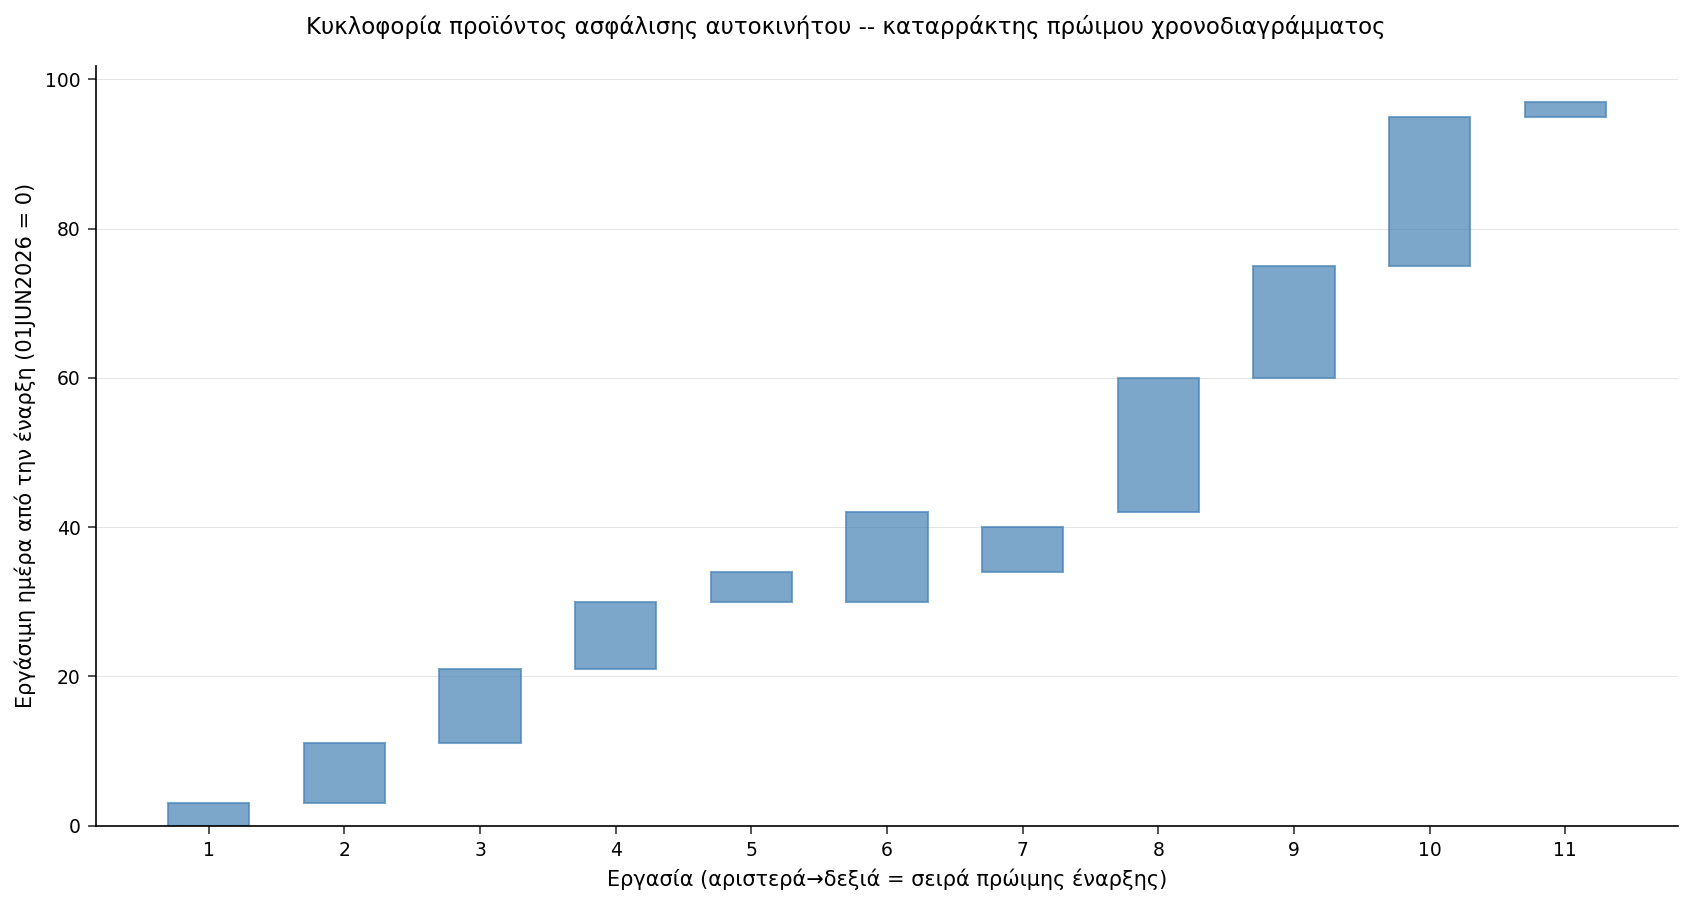

In [8]:
ΔΕΔΟΜΕΝΑ gantt; ΟΡΙΣΜΟΣ sched_es;
   ord = es;          /* numeric x = early-start order */
ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=gantt; ΚΑΤΑ ord activity; ΕΚΤΕΛΕΣΗ;
ΔΕΔΟΜΕΝΑ gantt; ΟΡΙΣΜΟΣ gantt; ax = _n_; ΕΚΤΕΛΕΣΗ;   /* compact 1..11 x index */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITLE 'Κυκλοφορία προϊόντος ασφάλισης αυτοκινήτου -- καταρράκτης πρώιμου χρονοδιαγράμματος';
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ΕΤΙΚΕΤΑ='Εργασία (αριστερά→δεξιά = σειρά πρώιμης έναρξης)'
         integer VALUES=(1 ΕΩΣ 11 ΚΑΤΑ 1);
   YAXIS ΕΤΙΚΕΤΑ='Εργάσιμη ημέρα από την έναρξη (01JUN2026 = 0)' grid;
ΕΚΤΕΛΕΣΗ;
ODS GRAPHICS OFF;

Διαβάζοντας από αριστερά προς τα δεξιά, οι ράβδοι ανεβαίνουν συνεχώς την κρίσιμη αλυσίδα. Οι δύο εργασίες των οποίων οι ράβδοι σπάνε τη σκάλα -- ξεκινώντας χαμηλότερα από την κορυφή της προηγούμενης ράβδου -- είναι η κατάθεση ασφαλίστρων και η έγκριση, οι δραστηριότητες που φέρουν χαλαρότητα.

## Συνολικό περιθώριο ανά εργασία

Η απεικόνιση του συνολικού περιθωρίου κάθε εργασίας κάνει την κρίσιμη διαδρομή αναμφισβήτητη: κάθε κρίσιμη εργασία βρίσκεται στο μηδέν, και μόνο οι δύο ρυθμιστικές εργασίες ανεβαίνουν πάνω από αυτό.

                               Συνολικό περιθώριο ανά εργασία (0 = στην κρίσιμη διαδρομή)                               




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Συνολικό περιθώριο ανά εργασία (0 = στην κρίσιμη διαδρομή).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


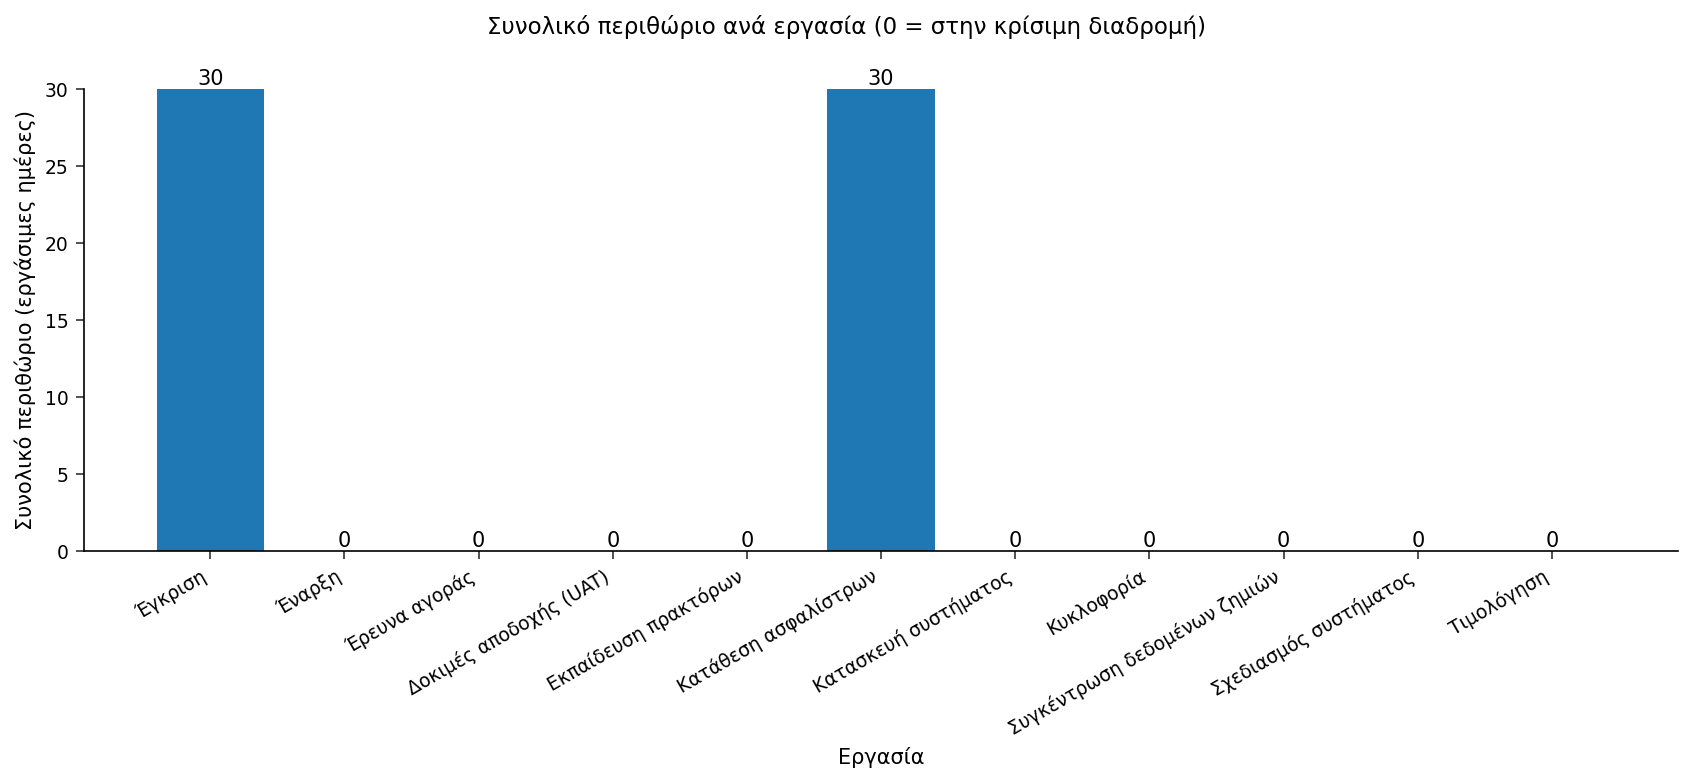

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITLE 'Συνολικό περιθώριο ανά εργασία (0 = στην κρίσιμη διαδρομή)';
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ΕΤΙΚΕΤΑ='Εργασία' fitpolicy=rotatethin;
   YAXIS ΕΤΙΚΕΤΑ='Συνολικό περιθώριο (εργάσιμες ημέρες)';
ΕΚΤΕΛΕΣΗ;
ODS GRAPHICS OFF;

## Φόρτωση πόρων υπό το πρώιμο χρονοδιάγραμμα

Πέρα από τον χρονισμό, το σχέδιο ανταγωνίζεται για δύο δεξαμενές ειδικών. Επεκτείνοντας κάθε εργασία στις εργάσιμες ημέρες που καταλαμβάνει και αθροίζοντας την ημερήσια ζήτηση προκύπτει το προφίλ φόρτωσης πόρων -- πόσους αναλογιστές και προγραμματιστές χρειάζεται το σχέδιο κάθε ημέρα, αν κάθε εργασία ξεκινά όσο το δυνατόν νωρίτερα. Η αιχμή είναι η μέγιστη δυναμικότητα που απαιτεί ποτέ το πρόγραμμα ταυτόχρονα.

                                 Μέγιστη ημερήσια φόρτωση πόρων (πρώιμο χρονοδιάγραμμα)                                 

                                                  The MEANS Procedure

 Variable    Label                              Maximum
 ------------------------------------------------------
 ACTUARIES   Αναλογιστές                              3
 DEVELOPERS  Προγραμματιστές                          3
 ------------------------------------------------------

                        Ημερήσια φόρτωση αναλογιστών & προγραμματιστών στο πρώιμο χρονοδιάγραμμα                        




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Μέγιστη ημερήσια φόρτωση πόρων (πρώιμο χρονοδιάγραμμα).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Ημερήσια φόρτωση αναλογιστών & προγραμματιστών στο πρώιμο χρονοδιάγραμμα.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


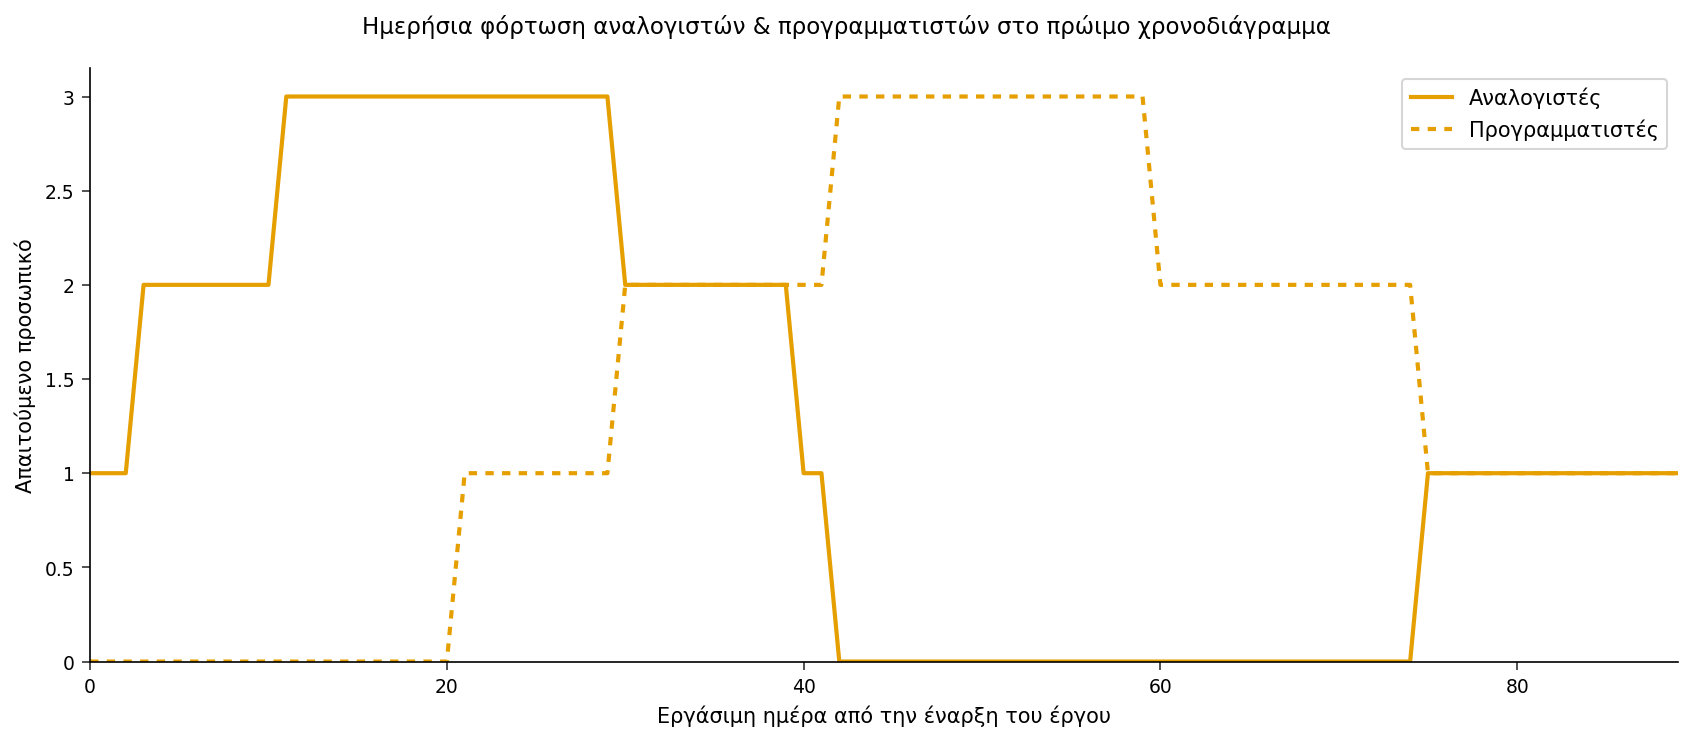

In [10]:
ΔΕΔΟΜΕΝΑ LOAD;
   ΟΡΙΣΜΟΣ sched;
   ΕΠΑΝΑΛΗΨΗ d = es ΕΩΣ ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ day a_use d_use;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=LOAD NOPRINT NWAY;
   ΚΛΑΣΗ day;
   ΜΕΤΑΒΛΗΤΗ a_use d_use;
   ΕΞΟΔΟΣ out=rprofile(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=rprofile; ΚΑΤΑ day; ΕΚΤΕΛΕΣΗ;

TITLE 'Μέγιστη ημερήσια φόρτωση πόρων (πρώιμο χρονοδιάγραμμα)';
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=rprofile MAX maxdec=0;
   ΜΕΤΑΒΛΗΤΗ actuaries developers;
   ΕΤΙΚΕΤΑ actuaries='Αναλογιστές' developers='Προγραμματιστές';
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITLE 'Ημερήσια φόρτωση αναλογιστών & προγραμματιστών στο πρώιμο χρονοδιάγραμμα';
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Αναλογιστές';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Προγραμματιστές';
   XAXIS ΕΤΙΚΕΤΑ='Εργάσιμη ημέρα από την έναρξη του έργου';
   YAXIS ΕΤΙΚΕΤΑ='Απαιτούμενο προσωπικό' MIN=0;
   keylegend / location=inside position=topright;
ΕΚΤΕΛΕΣΗ;
ODS GRAPHICS OFF;

## Ερμηνεία των αποτελεσμάτων

- **Η ημερομηνία κυκλοφορίας καθορίζεται από τον κλάδο κατασκευής, όχι από τον ρυθμιστικό κλάδο.** Η κρίσιμη διαδρομή διατρέχει Έναρξη -> Έρευνα αγοράς -> Συγκέντρωση δεδομένων ζημιών -> Τιμολόγηση -> Σχεδιασμός συστήματος -> Κατασκευή συστήματος -> Δοκιμές αποδοχής (UAT) -> Εκπαίδευση πρακτόρων -> Κυκλοφορία, για ένα makespan 97 εργάσιμων ημερών (με ολοκλήρωση στην 13OCT2026). Κάθε μία από αυτές τις εργασίες έχει μηδενικό περιθώριο, οπότε οποιαδήποτε καθυστέρηση σε αυτές σπρώχνει την κυκλοφορία ισόποσα.

- **Ο ρυθμιστικός κλάδος έχει έναν μήνα χαλαρότητας.** Η κατάθεση ασφαλίστρων και η έγκριση φέρουν καθεμία 30 εργάσιμες ημέρες συνολικού περιθωρίου. Αφού λήξει η τιμολόγηση, μπορούν να ξεκινήσουν το αργότερο έως τις οψιμότερες ημερομηνίες έναρξής τους και να επανενωθούν εγκαίρως στην εκπαίδευση πρακτόρων, επειδή ο παράλληλος κλάδος κατασκευής του συστήματος (σχεδιασμός συστήματος -> κατασκευή συστήματος -> UAT) είναι ο μακρύτερος από τις δύο διαδρομές που τροφοδοτούν την κυκλοφορία. Σε όρους σχεδιασμού, η κατάθεση *δεν* είναι εδώ ο δεσμευτικός περιορισμός -- η κατασκευή του συστήματος συμβολαίων είναι.

- **Η ζήτηση ειδικών κορυφώνεται σε διαφορετικές φάσεις.** Το προφίλ φόρτωσης δείχνει τη ζήτηση αναλογιστών να κορυφώνεται νωρίς (έως την τιμολόγηση) και τη ζήτηση προγραμματιστών να κορυφώνεται αργότερα (έως την κατασκευή του συστήματος), με καθεμία να φτάνει στα τρία άτομα ανά ημέρα. Επειδή οι δύο αιχμές πέφτουν σε διαφορετικές φάσεις, μια μικρή, διαδοχική ομάδα ειδικών μπορεί να στελεχώσει το σχέδιο -- το πρόγραμμα δεν χρειάζεται ταυτόχρονα τον μέγιστο αριθμό αναλογιστών και προγραμματιστών.

**Επιχειρησιακό συμπέρασμα.** Η CPM μετατρέπει μια λίστα εργασιών κυκλοφορίας σε ένα αξιοποιήσιμο χρονοδιάγραμμα: εντοπίζει τις δραστηριότητες του κλάδου κατασκευής που ο ασφαλιστής πρέπει να προστατεύσει για να πετύχει την 13OCT2026, ποσοτικοποιεί τον μήνα χαλαρότητας που είναι διαθέσιμος στη ρυθμιστική κατάθεση, και δείχνει ότι οι κλιμακωτές αιχμές αναλογιστών και προγραμματιστών επιτρέπουν σε μια λιτή ομάδα ειδικών να υλοποιήσει το σχέδιο.

*Σημείωση υλοποίησης:* Το SAS το υπολογίζει αυτό με το PROC CPM (SAS/OR). Το Jenner φτάνει στο ίδιο αποτέλεσμα κρίσιμης διαδρομής εμπρός/πίσω με το PROC OPTMODEL, λύνοντας τα δύο γραμμικά προγράμματα μακρύτερης διαδρομής που υποστηρίζουν τη μέθοδο.